# Weak Lensing Convergence with Born Approximation

This notebook demonstrates the lensing API for computing convergence maps from N-body lightcones.

We will:
1. Reuse the N-body simulation from `03-nbody-simulation.ipynb`
2. Wrap the lightcone in a `SphericalDensity` container
3. Compute convergence using `born()`
4. Demonstrate resampling with `ud_sample()`
5. Explore multiple source redshifts (tomographic bins)

In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["JAX_PLATFORMS"] = "cpu"

import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax_cosmo as jc

from fwd_model_tools.field import FieldStatus, ParticleField, DensityField, FlatDensity, SphericalDensity
from fwd_model_tools.normal import gaussian_initial_conditions
from fwd_model_tools.pm import lpt, nbody
from fwd_model_tools.lensing_model import Planck18
# Import lensing API
from fwd_model_tools.lensing import born
from fwd_model_tools.field import SphericalDensity, DensityStatus
from fwd_model_tools.utils import compute_snapshot_scale_factors

/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound
ERROR:2025-11-17 10:58:54,152:jax._src.xla_bridge:473: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 471, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_plugins/xla_cud

## Wrap Lightcone in SphericalDensity

The N-body simulation provides painted density planes. We wrap them in a `SphericalDensity` object with proper metadata.

In [2]:
# Simulation parameters
mesh_size = (256, 256, 256)
mesh_size = (64, 64, 64)
box_size = (2000.0, 2000.0, 2000.0)  # in Mpc/h
observer_position = (0.5, 0.5, 0.5)
nside = 256
flatsky_npix = (256, 256)

# N-body parameters
t0 = 0.1  # Initial scale factor
t1 = 1.0  # Final scale factor (present day)
dt0 = 0.05  # Time step

# Random seed
key = jax.random.PRNGKey(42)
cosmo = Planck18()

print(f"Mesh size: {mesh_size}")
print(f"Box size: {box_size} Mpc/h")

Mesh size: (64, 64, 64)
Box size: (2000.0, 2000.0, 2000.0) Mpc/h


In [3]:
gaussian_field = gaussian_initial_conditions(
    key=key,
    cosmo=cosmo,
    mesh_size=mesh_size,
    box_size=box_size,
    observer_position=observer_position,
    nside=nside,
    flatsky_npix=flatsky_npix,
)

print(f"Initial field: {gaussian_field}")
print(f"Status: {gaussian_field.status}")

Initial field: DensityField(array=Array(64, 64, 64), mesh_size=(64, 64, 64), box_size=(2000.0, 2000.0, 2000.0), status=initial_field, scale_factors_shape=(1,))
Status: FieldStatus.INITIAL_FIELD


In [4]:
dx_field, p_field = lpt(cosmo, gaussian_field, a=t0, order=1)

print(f"Displacement field: {dx_field}")
print(f"Array shape: {dx_field.array.shape}")
print(f"Scale factors: {dx_field.scale_factors}")

# Compute number of shells from field properties
nb_shells = 3
max_radius = dx_field.max_comoving_radius
density_plane_width = dx_field.density_width(nb_shells=nb_shells)
print(f"Max comoving radius: {max_radius} Mpc/h")
print(f"Density plane width: {density_plane_width} Mpc/h")
print(f"Number of shells: {nb_shells}")

shape of initial force: (64, 64, 64, 3)
growth factor shape: (1,)
Displacement field: ParticleField(array=Array(64, 64, 64, 3), mesh_size=(64, 64, 64), box_size=(2000.0, 2000.0, 2000.0), status=lpt1, scale_factors_shape=(1,))
Array shape: (64, 64, 64, 3)
Scale factors: [0.1]
Max comoving radius: 1000.0 Mpc/h
Density plane width: 333.3333333333333 Mpc/h
Number of shells: 3


In [5]:
# Run N-body with geometry=None to save 3D density fields
max_scale_factor = jc.background.a_of_chi(cosmo, dx_field.max_comoving_radius).squeeze()
ts = compute_snapshot_scale_factors(cosmo, dx_field , nb_shells)
particle_lightcone = nbody(
    cosmo,
    dx_field,
    p_field,
    t1=t1,
    dt0=dt0,
    ts=ts,
    geometry='particles',
)

print(f"Particle snapshots: {particle_lightcone}")
print(f"Array shape: {particle_lightcone.array.shape}")
print(f"Scale factors shape: {particle_lightcone.scale_factors.shape}")

Particle snapshots: ParticleField(array=Array(3, 64, 64, 64, 3), mesh_size=(64, 64, 64), box_size=(2000.0, 2000.0, 2000.0), status=lpt1, scale_factors_shape=(3,))
Array shape: (3, 64, 64, 64, 3)
Scale factors shape: (3,)


In [6]:
spherical_lightcone = particle_lightcone.paint_spherical(center=ts)
flat_lightcone = particle_lightcone.paint_2d(center=ts)

/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int64 to dtype=int32 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(


## Compute Convergence with born()

The `born()` function provides a clean, functional API:

```python
kappa = born(cosmo, lightcone, z_source)
```

Similar to `lpt(cosmo, density_field, a, order)`

In [7]:
kappa_spherical = born(cosmo, spherical_lightcone, z_source=1.0)

print(f"Kappa shape: {kappa_spherical.array.shape}")
print(f"Kappa type: {type(kappa_spherical).__name__}")
print(f"Source redshift: {kappa_spherical.z_source}")

Kappa shape: (786432,)
Kappa type: SphericalKappaField
Source redshift: 1.0


## Visualize Convergence Map

/tmp/ipykernel_94891/4204924938.py:3: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


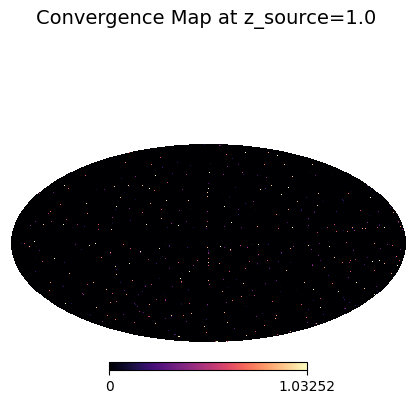

In [9]:
kappa_spherical.plot()
plt.suptitle("Convergence Map at z_source=1.0", fontsize=14)
plt.tight_layout()

## Multiple Source Planes (Tomographic Bins)

Compute convergence for multiple source redshifts simultaneously.

In [10]:
z_sources = jnp.array([0.5, 1.0, 1.5, 2.0])
kappa_multi = born(cosmo, spherical_lightcone, z_source=z_sources)

print(f"Multi-source kappa shape: {kappa_multi.array.shape}")
print(f"Number of tomographic bins: {len(z_sources)}")

Multi-source kappa shape: (4, 786432)
Number of tomographic bins: 4


## Visualize All Tomographic Bins

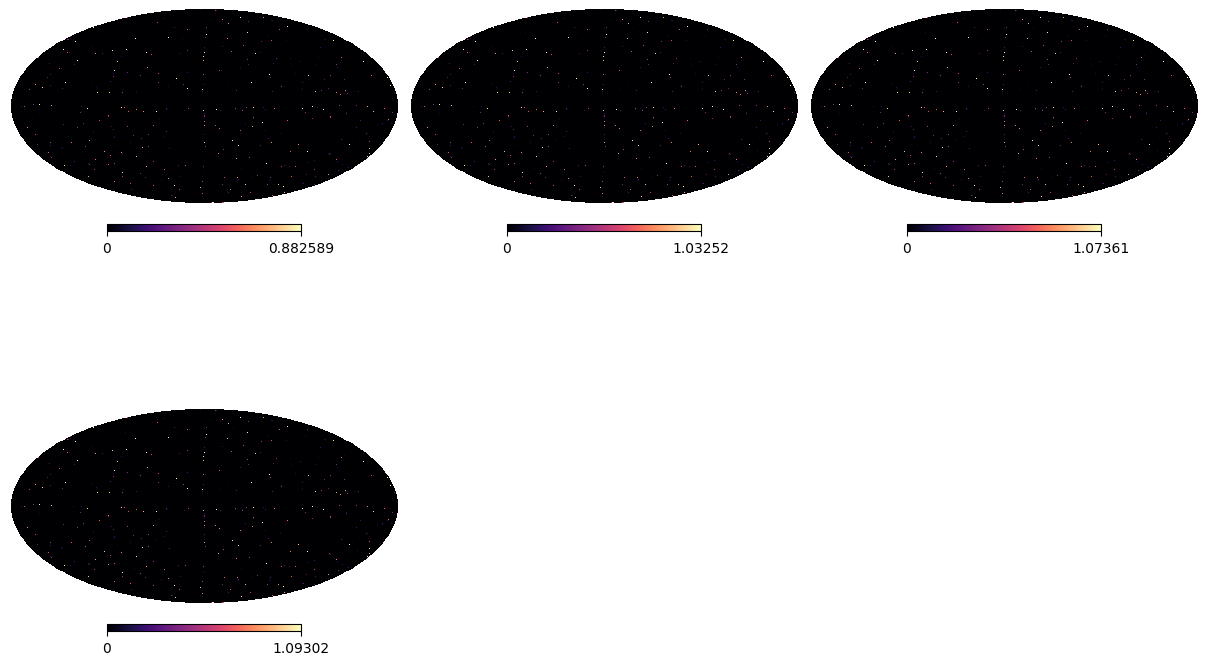

In [11]:
kappa_multi.show()

## Resolution Resampling with ud_sample()

The `ud_sample()` method allows upsampling and downsampling using `jax_healpy.ud_grade`.

### Upsampling

In [13]:
kappa_hires = kappa_spherical.ud_sample(new_nside=256)

print(f"Original: nside={kappa_spherical.nside}, npix={kappa_spherical.array.size}")
print(f"Upsampled: nside={kappa_hires.nside}, npix={kappa_hires.array.size}")

Original: nside=256, npix=786432
Upsampled: nside=256, npix=786432


## Compare Original vs Upsampled

TypeError: SphericalDensity.plot() got an unexpected keyword argument 'ax'

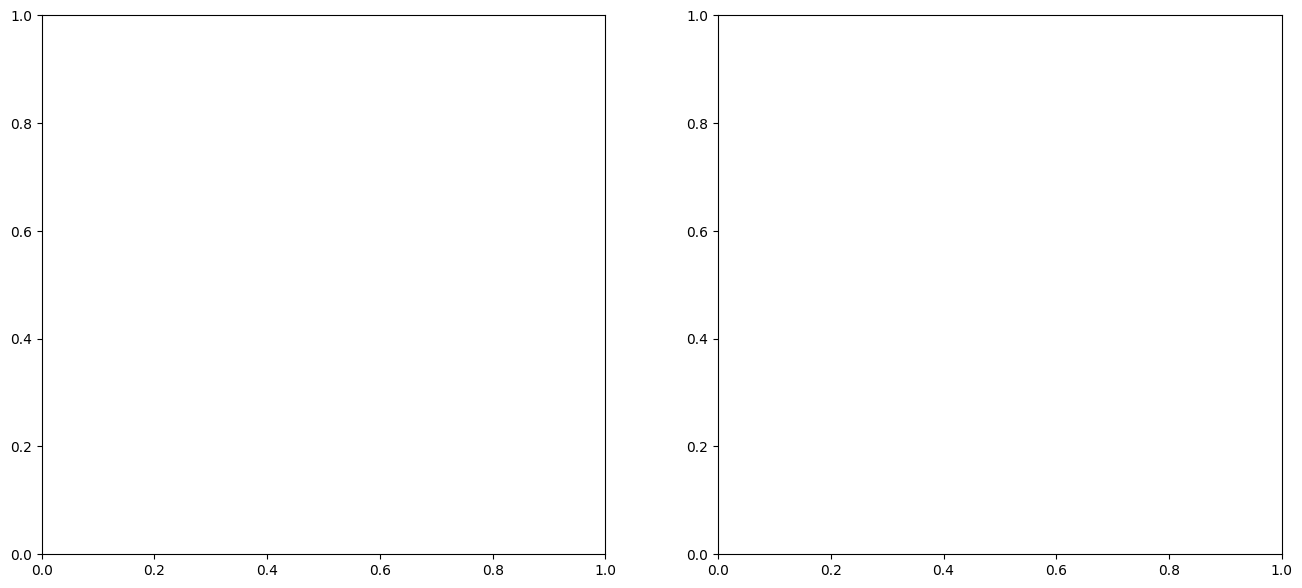

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

kappa_spherical.plot(ax=axes[0], show_colorbar=True)
axes[0].set_title(f"Original (nside={kappa_spherical.nside})")

kappa_hires.plot(ax=axes[1], show_colorbar=True)
axes[1].set_title(f"Upsampled (nside={kappa_hires.nside})")

plt.tight_layout()

### Downsampling

In [ ]:
kappa_lowres = kappa.ud_sample(new_nside=64)

kappa_lowres.plot()
plt.suptitle(f"Downsampled (nside={kappa_lowres.nside})", fontsize=14)
plt.tight_layout()

## Convergence Statistics

Examine basic statistical properties of the convergence maps.

In [ ]:
print("Single source (z=1.0):")
print(f"  Mean convergence: {jnp.mean(kappa.array):.6f}")
print(f"  Std convergence: {jnp.std(kappa.array):.6f}")
print(f"  Min/Max: {jnp.min(kappa.array):.6f} / {jnp.max(kappa.array):.6f}")
print()

print("Multiple sources (tomographic bins):")
for i, z in enumerate(z_sources):
    mean = jnp.mean(kappa_multi[i].array)
    std = jnp.std(kappa_multi[i].array)
    print(f"  Bin {i} (z={z}): mean={mean:.6f}, std={std:.6f}")

In [ ]:
z_sources = jnp.array([0.5, 1.0, 1.5, 2.0])
kappa_multi = born(cosmo, flat_lightcone, z_source=z_sources)

print(f"Multi-source kappa shape: {kappa_multi.array.shape}")
print(f"Number of tomographic bins: {len(z_sources)}")

## Future Functionality

The following methods are planned but not yet implemented:
- `compute_power_spectrum(ell_bins)`: Compute angular power spectrum C_ℓ
- `get_shear()`: Derive shear (γ1, γ2) from convergence

Let's try calling them to see the error messages:

In [ ]:
try:
    C_ell = kappa.compute_power_spectrum(ell_bins=jnp.logspace(1, 3, 10))
except NotImplementedError as e:
    print(f"Power spectrum: {e}")

try:
    gamma = kappa.get_shear()
except NotImplementedError as e:
    print(f"Shear: {e}")

## Summary

In this notebook, we demonstrated:

1. Wrapping N-body lightcones in `SphericalDensity` containers
2. Computing convergence maps using the functional `born()` API
3. Handling multiple source redshifts (tomographic bins)
4. Resampling convergence maps with `ud_sample()`
5. Visualizing and analyzing convergence statistics

The API provides a clean, functional interface similar to `lpt(cosmo, field, a, order)`, making it easy to integrate lensing computations into inference workflows.